In [1]:
from data_analysis import *
import pandas as pd
from functools import reduce
from prince import MCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import copy

# Partie 2 - Données Images

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/constance/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2


## 1. Analyse du jeu de données

In [3]:
faces = Celeb_Faces(path)
faces.load_data()

### Analyse descriptive du jeu de données

Pour cette analyse descriptive on se base uniquement sur les fichiers CSV descriptifs des images et non pas les images directement.

In [4]:
analyzers = {} 

for key, df in faces.data.items():
    if df is not None:
        print(f"\n Analyse de : {key}")
        analyzers[key] = Analyzer(df) 
        inventory = analyzers[key].get_inventory()
        print(inventory)


 Analyse de : attr_df
Dataset ready: 202599 rows and 41 columns.
                 Column   Type  Cardinality  Missing                   Details
0              image_id    str       202599        0  Examples: ['000001.jpg']
1      5_o_Clock_Shadow  int64            2        0    Unique values: [-1, 1]
2       Arched_Eyebrows  int64            2        0    Unique values: [1, -1]
3            Attractive  int64            2        0    Unique values: [1, -1]
4       Bags_Under_Eyes  int64            2        0    Unique values: [-1, 1]
5                  Bald  int64            2        0    Unique values: [-1, 1]
6                 Bangs  int64            2        0    Unique values: [-1, 1]
7              Big_Lips  int64            2        0    Unique values: [-1, 1]
8              Big_Nose  int64            2        0    Unique values: [-1, 1]
9            Black_Hair  int64            2        0    Unique values: [-1, 1]
10           Blond_Hair  int64            2        0    Unique va

- "Attr_df" contient les descriptions de chacune des images à travers une table de booléens pour indiquer si chacun de attributs est présent dans l'image en question.
- "Partition_df" contient les informations de la répartition du jeu de données en train/valid/test. Les images sont attribuées à une catégorie à partir de leur ID.
- "Bbox_df" contient les rectangles ciblant les visages de chacune des célébrités (pour chacune d'entre elles on dispose du coin inférieur gauche, de la largeur et de la hauteur).
- "Landmarks_df" contient les coordonnées (x,y) des yeux gauches et droits, du nez ainsi que des extrêmités gauches et droites de la bouche.


Aucune donnée n'est manquante.

Les dataframes attr_df, bbox_df et landmarks_df sont intéressants pour comprendre ce qui est perçu comme étant attirant. En revanche pour l'instant parition_df ne présente pas grand intérêt. Il convient toutefois de le regarder afin de vérifier que les distributions entre train/valid/test au niveau des différentes features sont bien cohérentes entre elles (ie pas d'excès ou de défaut trop important dans l'une des catégories).

A présent je veux merge l'ensemble des tableaux pour faire un super tableau (on image_id) à partir duquel regarder les corrélations des différentes variables vis-à-vis de l'attractivité.

In [5]:
faces_global= reduce(lambda left, right: left.merge(right, on='image_id', how='outer'), faces.data.values())
print(faces_global)
global_analyser = Analyzer(faces_global)

          image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  \
0       000001.jpg                -1                1           1   
1       000002.jpg                -1               -1          -1   
2       000003.jpg                -1               -1          -1   
3       000004.jpg                -1               -1           1   
4       000005.jpg                -1                1           1   
...            ...               ...              ...         ...   
202594  202595.jpg                -1               -1           1   
202595  202596.jpg                -1               -1          -1   
202596  202597.jpg                -1               -1          -1   
202597  202598.jpg                -1                1           1   
202598  202599.jpg                -1                1           1   

        Bags_Under_Eyes  Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  \
0                    -1    -1     -1        -1        -1          -1  ...   
1                



In [6]:
global_analyser.plot_distributions()

### Analyse des corrélations entre attributs. Quelles sont les variables les plus corrélées ? Exhiber au moins une corrélation artificielle. Commenter.

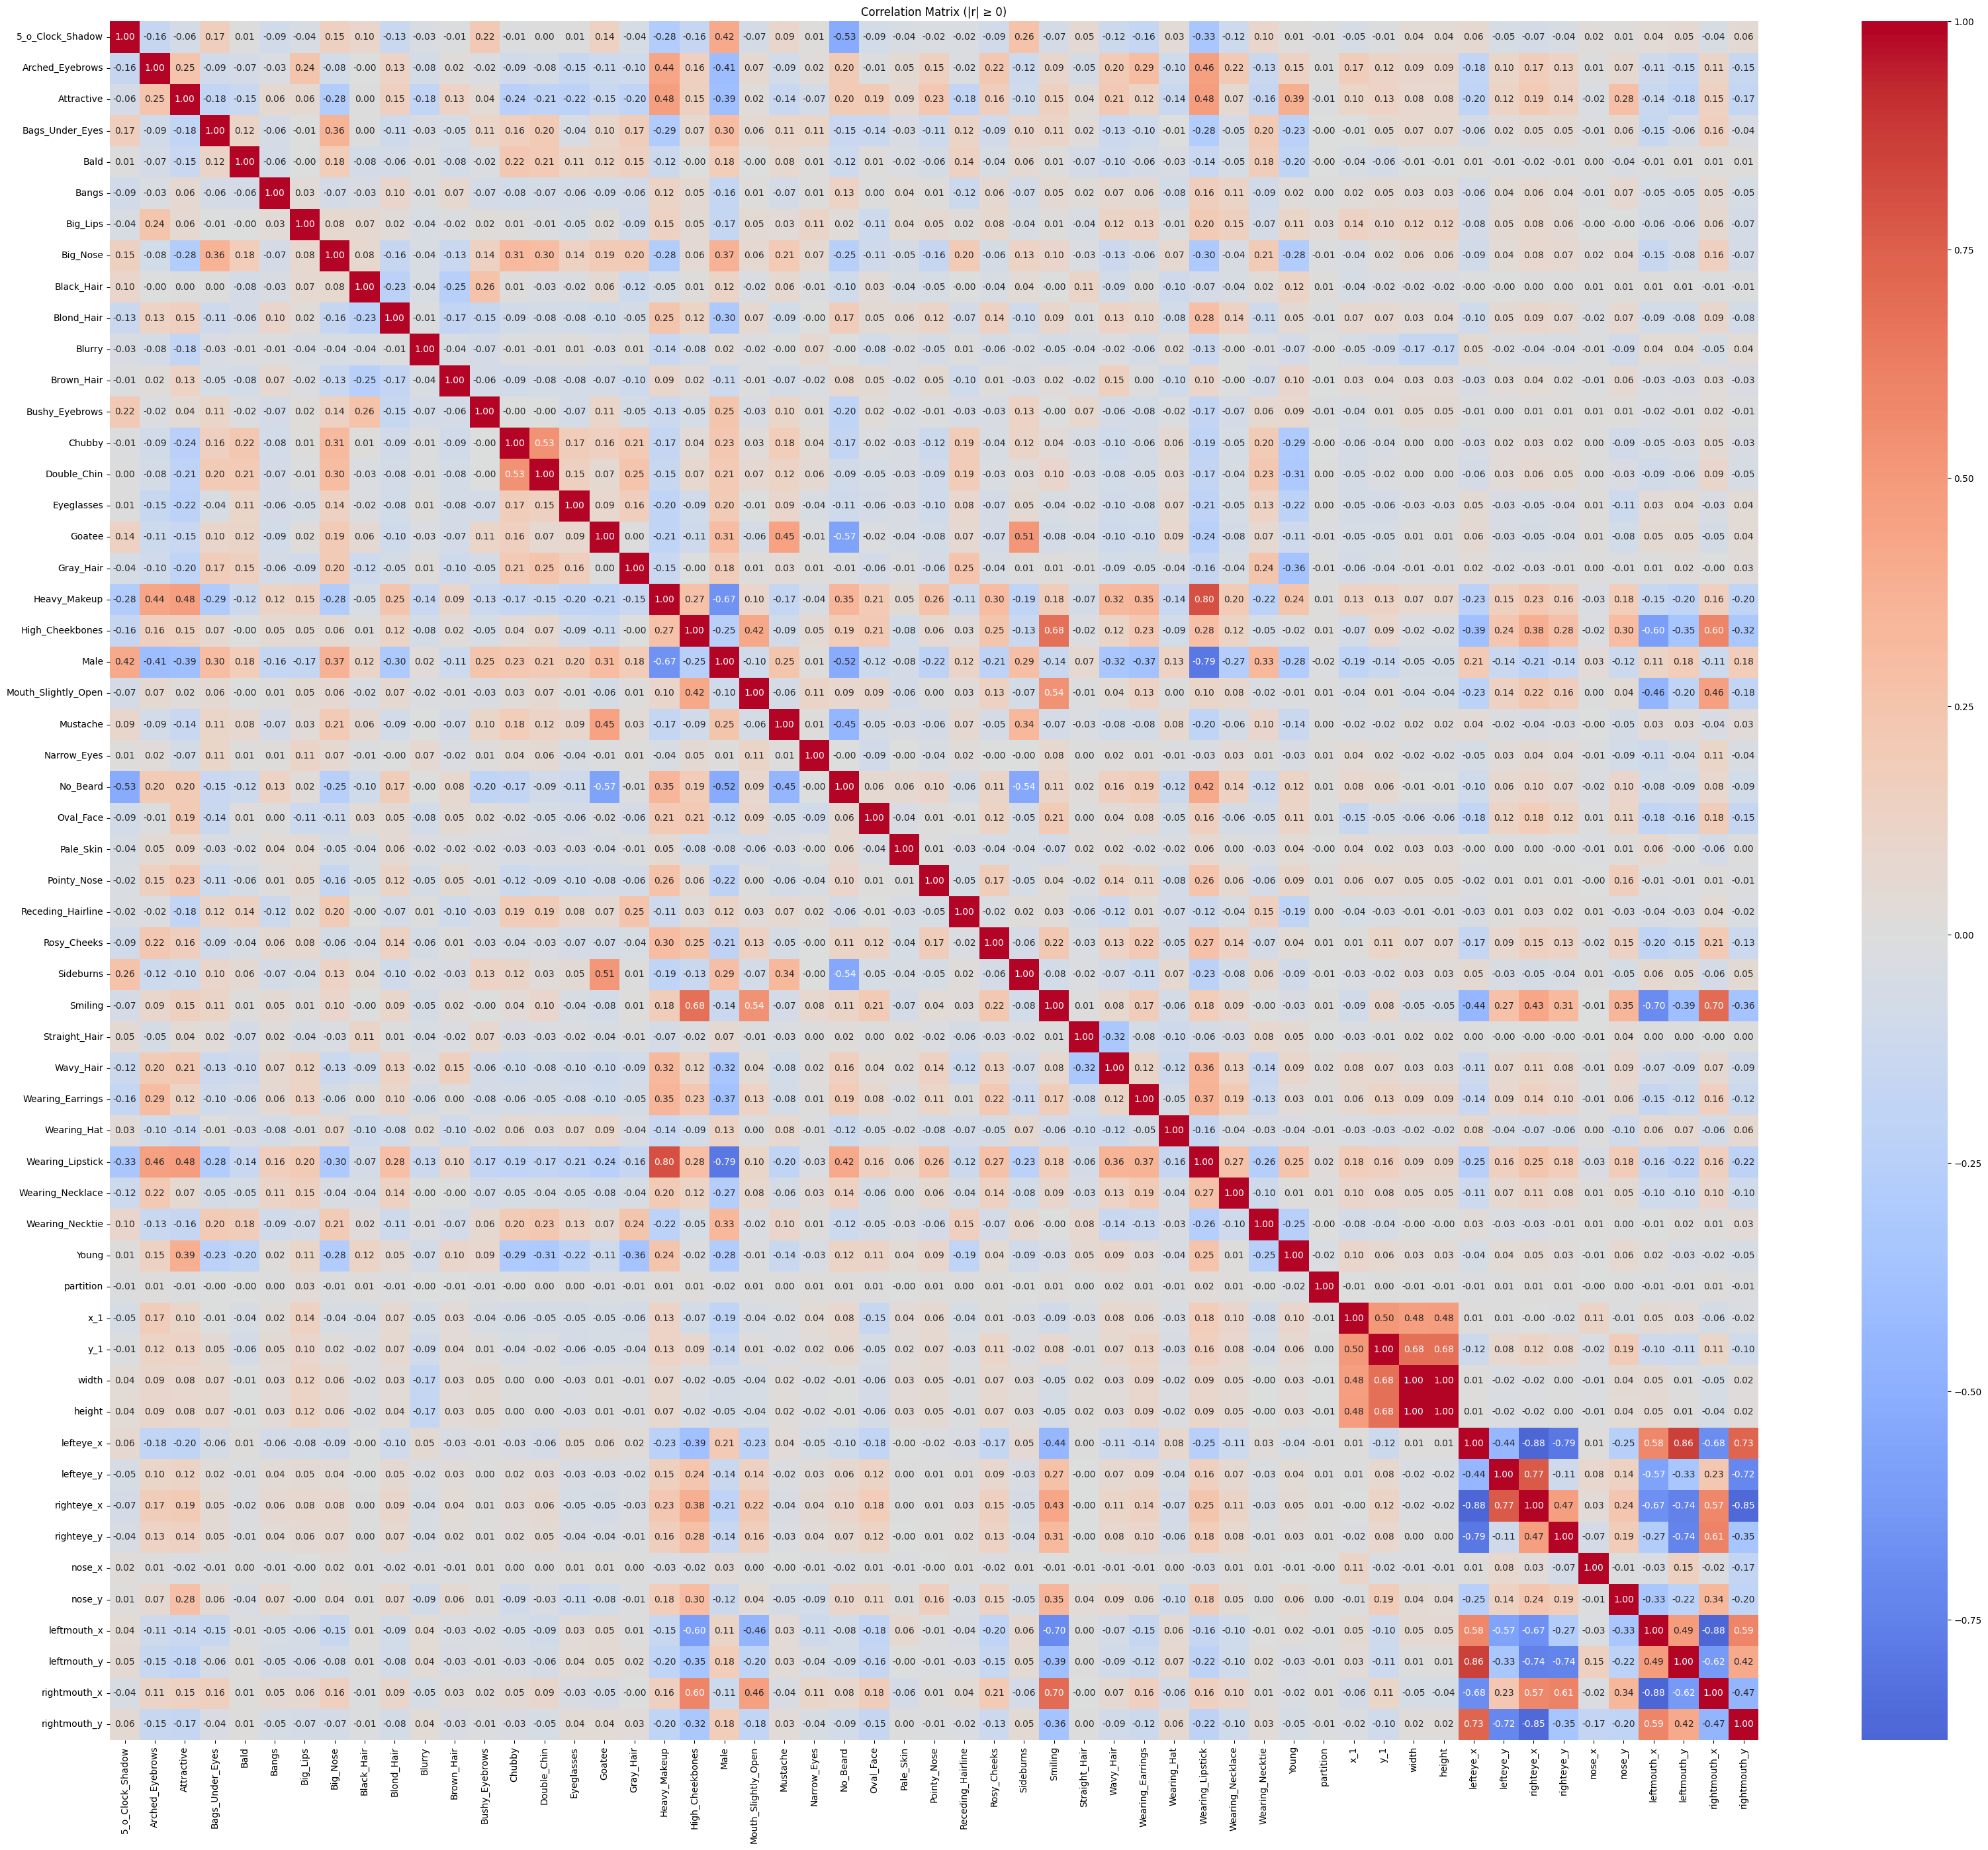

In [7]:
global_analyser.plot_matrix_correlation(0)

On voit bien que les données provenant des dataframs bbox et landmarks sont très corrélées entre elles. Ce qui est logique puisque les positions des attributs dépendent globalement de la position des autres. On voit mal un nez, par exemple, être situé au niveau de la bouche.

Pour plus de lisibilité, on utilise maintenant un seuil à 0.5 pour ne garder que les variables les plus corrélées entre elles.

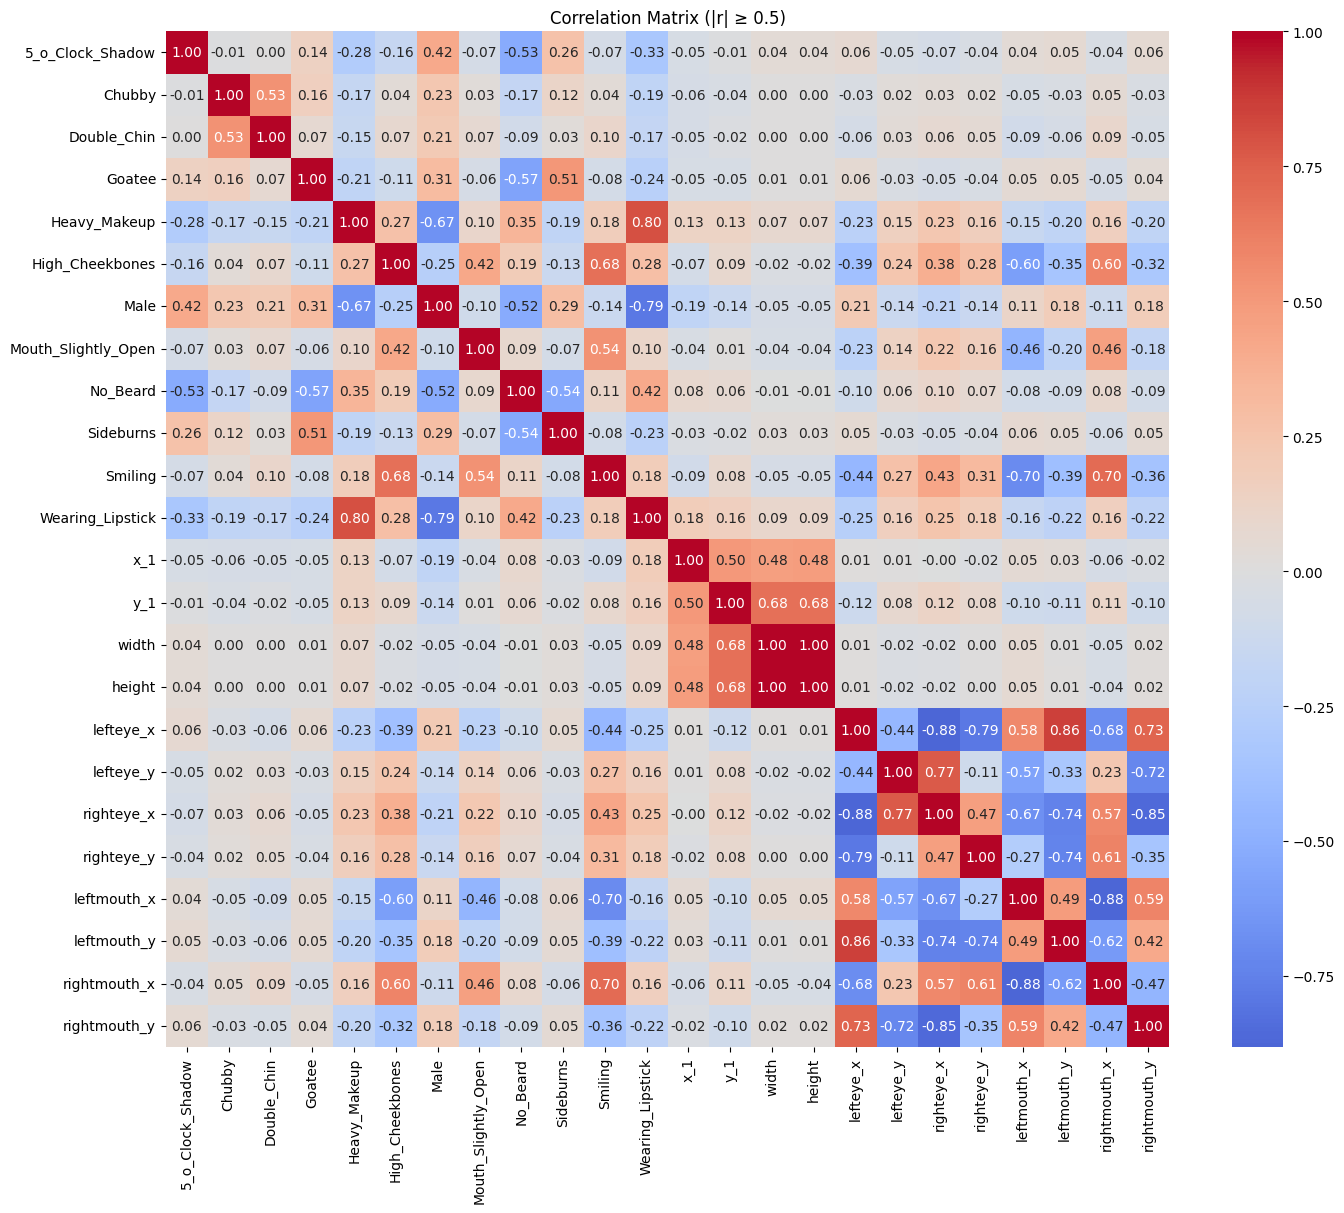

In [8]:
global_analyser.plot_matrix_correlation(0.5)

### Identification de variables sensibles (ex. Genre (male/female), Couleur de peau, Âge, Contexte culturel. Justifier votre classification (pour sont-elles sensibles ? …)

### Variables directement sensibles

| Variable | Motif |
|---|---|
| `Male` | Caractéristique protégée (genre) |
| `Young` | Caractéristique protégée (âge) |
| `Pale_Skin` | Proxy direct de l'ethnie/couleur de peau (Art. 9 RGPD) |
| `Attractive` | Jugement subjectif sur l'apparence physique |
| `Chubby` | Donnée corporelle relevant de la vie privée |

### Variables à risque indirect (proxys potentiels)

| Variable | Biais potentiel |
|---|---|
| `Heavy_Makeup`, `Wearing_Lipstick` | Fortement corrélées au genre perçu |
| `No_Beard`, `Goatee`, `Mustache`, `Sideburns` | Proxy du genre masculin |
| `Wearing_Earrings`, `Wearing_Necklace` | Marqueurs de genre stéréotypés |
| `Wearing_Hat` | Peut refléter une appartenance culturelle ou religieuse |
| `Big_Nose`, `Big_Lips` | Attributs subjectifs potentiellement corrélés à l'ethnie |
| `Gray_Hair`, `Receding_Hairline` | Proxys de l'âge avancé |

### Analyse de disparité: Certains groupes sont-ils sous-représentés ? Le dataset reflète-t-il un biais de collecte ? Révèle-t-il d’autres biais ?

Afin de ne pas définir les groupes à la main, on utilise une analyse de correspondance multiple afin de définir des personnas. L'idée est ensuite de compter leur nombre et de décrire ceux-ci pour identifier les différents biais. On se base uniquement sur le dataframe attr_df pour cette analyse.

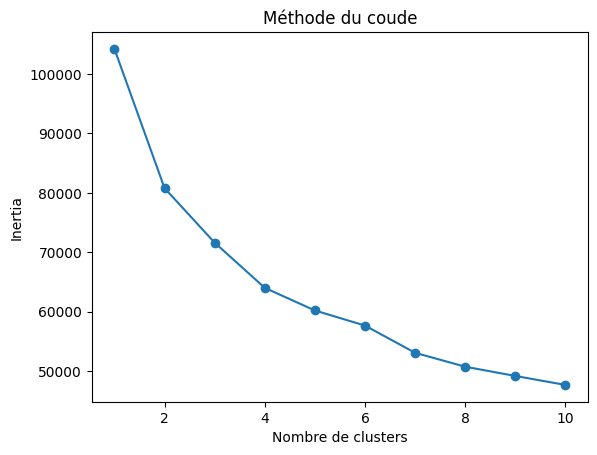

In [9]:
df_num = faces.data["attr_df"].drop(columns=['image_id']).copy()  # numérique (-1/1)
df_cat = df_num.astype(str)  # pour MCA

mca = MCA(n_components=10, random_state=42)
X_mca = mca.fit_transform(df_cat)

inertia = []
K = range(1, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_mca)
    inertia.append(km.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertia")
plt.title("Méthode du coude")
plt.show()

In [10]:
k_opt = 6  
kmeans = KMeans(n_clusters=k_opt, random_state=42)
df_num["persona"] = kmeans.fit_predict(X_mca)

In [11]:
centroids = kmeans.cluster_centers_  # shape = (k_opt, n_components)

from scipy.spatial.distance import cdist

distances = cdist(X_mca, centroids, metric='euclidean')  # shape = (n_individus, k_opt)

similarity_scores = 1 / (1 + distances)  
similarity_scores.shape

(202599, 6)

In [12]:
intra_scores = []

for c in range(k_opt):
    members = np.where(df_num["persona"] == c)[0]
    intra_scores.append(similarity_scores[members, c].mean())

print("Intra-cluster scores:", intra_scores)

Intra-cluster scores: [np.float64(0.6671642577566435), np.float64(0.6871670770541167), np.float64(0.6698208830078634), np.float64(0.6251655454781758), np.float64(0.6233028013506083), np.float64(0.6725455788227358)]


In [13]:
colonnes_attributs = [a for a in df_num.columns if a not in ['image_id', 'persona']]
print(colonnes_attributs)

['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']


In [14]:
df_bin = (df_num[colonnes_attributs] == 1).astype(int)
df_bin['persona'] = df_num['persona']

attribute_counts_raw = df_bin.groupby('persona')[colonnes_attributs].sum()
attribute_counts_raw['cluster_size'] = df_num.groupby('persona').size()

print(attribute_counts_raw)

         5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  Bald  \
persona                                                                         
0                   15454             2020       11607             9645   155   
1                     715             5221       15665             3825   168   
2                       1            42620       64700             5195     3   
3                     926              735         190             8077  3098   
4                    4526              970        2906             4766   970   
5                     894             2524        8765             9938   153   

         Bangs  Big_Lips  Big_Nose  Black_Hair  Blond_Hair  ...  Smiling  \
persona                                                     ...            
0         1241      4086      8996       11574         226  ...     8723   
1         8609      7935      3952        8778        4767  ...     1780   
2        15201     26667      6882       15694 

In [15]:
attribute_counts = attribute_counts_raw.assign(
    **{col: (attribute_counts_raw[col] / attribute_counts_raw['cluster_size']*100).round() 
       for col in attribute_counts_raw.columns if col != 'cluster_size'}
)

print(attribute_counts)

         5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  Bald  \
persona                                                                         
0                    66.0              9.0        49.0             41.0   1.0   
1                     2.0             11.0        34.0              8.0   0.0   
2                     0.0             55.0        84.0              7.0   0.0   
3                     6.0              5.0         1.0             57.0  22.0   
4                    30.0              7.0        19.0             32.0   7.0   
5                     3.0              9.0        32.0             37.0   1.0   

         Bangs  Big_Lips  Big_Nose  Black_Hair  Blond_Hair  ...  Smiling  \
persona                                                     ...            
0          5.0      17.0      38.0        49.0         1.0  ...     37.0   
1         19.0      17.0       9.0        19.0        10.0  ...      4.0   
2         20.0      35.0       9.0        20.0 

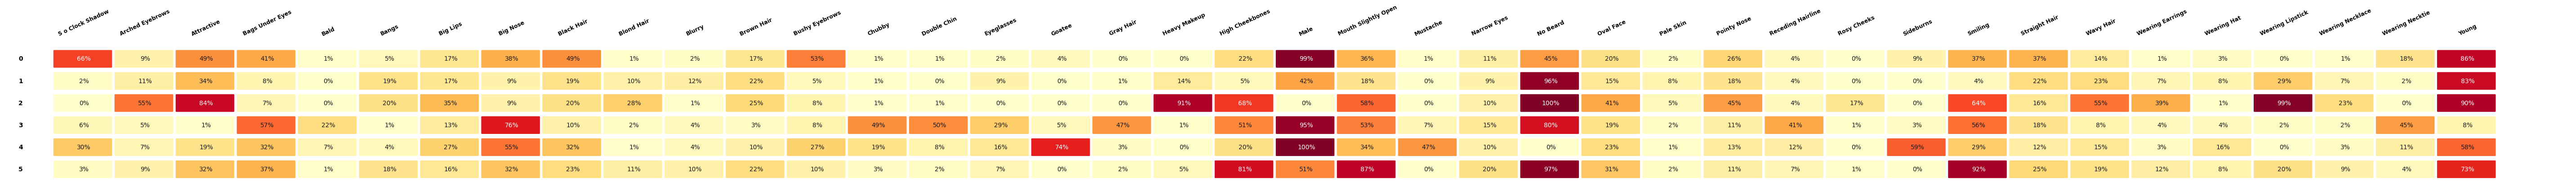

In [16]:
plot_table_attr(attribute_counts, colonnes_attributs)

In [17]:
bias_report(attribute_counts, colonnes_attributs)

── Personas biaisés (attributs > 70%) ──

🔴 2 (5 attributs forts)
   No_Beard               100.0%  ██████████
   Wearing_Lipstick        99.0%  █████████
   Heavy_Makeup            91.0%  █████████
   Young                   90.0%  █████████
   Attractive              84.0%  ████████

🔴 5 (5 attributs forts)
   No_Beard                97.0%  █████████
   Smiling                 92.0%  █████████
   Mouth_Slightly_Open     87.0%  ████████
   High_Cheekbones         81.0%  ████████
   Young                   73.0%  ███████

🔴 3 (3 attributs forts)
   Male                    95.0%  █████████
   No_Beard                80.0%  ████████
   Big_Nose                76.0%  ███████

🟡 0 (2 attributs forts)
   Male                    99.0%  █████████
   Young                   86.0%  ████████

🟡 1 (2 attributs forts)
   No_Beard                96.0%  █████████
   Young                   83.0%  ████████

🟡 4 (2 attributs forts)
   Male                   100.0%  ██████████
   Goatee                

# A compléter 

### Analyse de la fairness: nous allons nous intéresser aux deux métriques de fairness ci-dessous. Elles se basent sur un attribut sensible (S) et comparent avec un attribut à étudier (Y). Nous allons considérer deux attributs sensibles: Male et Pale_Skin. Calculer la valeur de ces métriques pour tous les autres attributs. 

In [18]:
m1_Male= demographic_parity(faces_global, "Attractive", "Male")
m2_Male= disparate_impact(faces_global, "Attractive", "Male")
print(m1_Male, m2_Male)

m1_PaleSkin= demographic_parity(faces_global, "Attractive", "Pale_Skin")
m2_PaleSkin= disparate_impact(faces_global, "Attractive", "Pale_Skin")
print(m1_PaleSkin, m2_PaleSkin)

-0.279739781538902 0.29380467017220324
-0.45104368728374766 0.06378640876166669


In [19]:
dict_demo_male={}
dict_disp_male={}

dict_demo_paleskin={}
dict_disp_paleskin={}

for column in faces_global.columns:
    if column not in ["Male", "Pale_Skin", "image_id"]:
        dict_demo_male[column]= demographic_parity(faces_global, column, "Male")
        dict_disp_male[column]= disparate_impact(faces_global, column, "Male")
        dict_demo_paleskin[column]= demographic_parity(faces_global, column, "Pale_Skin")
        dict_disp_paleskin[column]= disparate_impact(faces_global, column, "Pale_Skin")

print("dict_demo_male", dict_demo_male)
print("dict_disp_male", dict_disp_male)

print("dict_demo_paleskin", dict_demo_paleskin)
print("dict_disp_paleskin", dict_disp_paleskin)


dict_demo_male {'5_o_Clock_Shadow': 0.1109383560629618, 'Arched_Eyebrows': -0.2224295282800014, 'Attractive': -0.279739781538902, 'Bags_Under_Eyes': 0.08569637559908984, 'Bald': 0.02227552949422258, 'Bangs': -0.08296684583833089, 'Big_Lips': -0.11069649899555278, 'Big_Nose': 0.11523255297410154, 'Black_Hair': 0.009081979674134627, 'Blond_Hair': -0.13072621286383448, 'Blurry': -0.0031885646029842195, 'Brown_Hair': -0.07895399286274858, 'Bushy_Eyebrows': 0.06140701582929827, 'Chubby': 0.043351645368437164, 'Double_Chin': 0.035395041436532264, 'Eyeglasses': 0.03831706967951471, 'Goatee': 0.06263604460041756, 'Gray_Hair': 0.02947201121427056, 'Heavy_Makeup': -0.3846119674825641, 'High_Cheekbones': -0.19859426749391657, 'Mouth_Slightly_Open': -0.1295662861119749, 'Mustache': 0.041515505999536025, 'Narrow_Eyes': -0.014832254848247024, 'No_Beard': -0.330179319739979, 'Oval_Face': -0.10082478195844993, 'Pointy_Nose': -0.1420836233150213, 'Receding_Hairline': 0.018080049753453866, 'Rosy_Cheeks'

# A compléter

## 2. Apprentissage automatique

Avant de commencer l'entrainement, on veut vérifier que les proportions des différents attributs dans train/valid/test sont proches.

On merge les tableaux attr_df et partition_df afin de vérifier facilement les proportions dans chacun des splits pour les différents attributs.

In [20]:
attr_partition= faces.data["attr_df"].merge(faces.data["partition_df"], on='image_id', how='outer')
print(attr_partition)

nb_part = attr_partition['partition'].value_counts().sort_index()
print(nb_part)

          image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  \
0       000001.jpg                -1                1           1   
1       000002.jpg                -1               -1          -1   
2       000003.jpg                -1               -1          -1   
3       000004.jpg                -1               -1           1   
4       000005.jpg                -1                1           1   
...            ...               ...              ...         ...   
202594  202595.jpg                -1               -1           1   
202595  202596.jpg                -1               -1          -1   
202596  202597.jpg                -1               -1          -1   
202597  202598.jpg                -1                1           1   
202598  202599.jpg                -1                1           1   

        Bags_Under_Eyes  Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  \
0                    -1    -1     -1        -1        -1          -1  ...   
1                

On convertit les colonnes d'attributs en binaire afin de faciliter le groupby - notamment éviter tout problème avec les -1.

In [21]:
attr_binary = copy.deepcopy(attr_partition)
print(attr_binary)

          image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  \
0       000001.jpg                -1                1           1   
1       000002.jpg                -1               -1          -1   
2       000003.jpg                -1               -1          -1   
3       000004.jpg                -1               -1           1   
4       000005.jpg                -1                1           1   
...            ...               ...              ...         ...   
202594  202595.jpg                -1               -1           1   
202595  202596.jpg                -1               -1          -1   
202596  202597.jpg                -1               -1          -1   
202597  202598.jpg                -1                1           1   
202598  202599.jpg                -1                1           1   

        Bags_Under_Eyes  Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  ...  \
0                    -1    -1     -1        -1        -1          -1  ...   
1                

In [22]:
attr_binary[colonnes_attributs] = (attr_binary[colonnes_attributs] == 1).astype(int)
attr_binary = attr_binary.groupby('partition')[colonnes_attributs].sum()
print(attr_binary)

           5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
partition                                                                   
0                     18177            43278       83603            33280   
1                      2345             5134       10332             4121   
2                      1994             5678        9898             4045   

           Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  Blond_Hair  ...  \
partition                                                           ...   
0          3713  24685     39213     38341       38906       24267  ...   
1           411   2915      3044      4943        4144        3056  ...   
2           423   3109      6528      4232        5422        2660  ...   

           Sideburns  Smiling  Straight_Hair  Wavy_Hair  Wearing_Earrings  \
partition                                                                   
0               9156    78080          33947      51982             30362   
1      

On regarde les pourcentages de chacun des attributs présents dans chaque split.

In [23]:
attr_binary[colonnes_attributs] = (attr_binary[colonnes_attributs].div(attr_binary.index.map(nb_part), axis=0)*100).round()

print(attr_binary)

           5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
partition                                                                   
0                      11.0             27.0        51.0             20.0   
1                      12.0             26.0        52.0             21.0   
2                      10.0             28.0        50.0             20.0   

           Bald  Bangs  Big_Lips  Big_Nose  Black_Hair  Blond_Hair  ...  \
partition                                                           ...   
0           2.0   15.0      24.0      24.0        24.0        15.0  ...   
1           2.0   15.0      15.0      25.0        21.0        15.0  ...   
2           2.0   16.0      33.0      21.0        27.0        13.0  ...   

           Sideburns  Smiling  Straight_Hair  Wavy_Hair  Wearing_Earrings  \
partition                                                                   
0                6.0     48.0           21.0       32.0              19.0   
1      

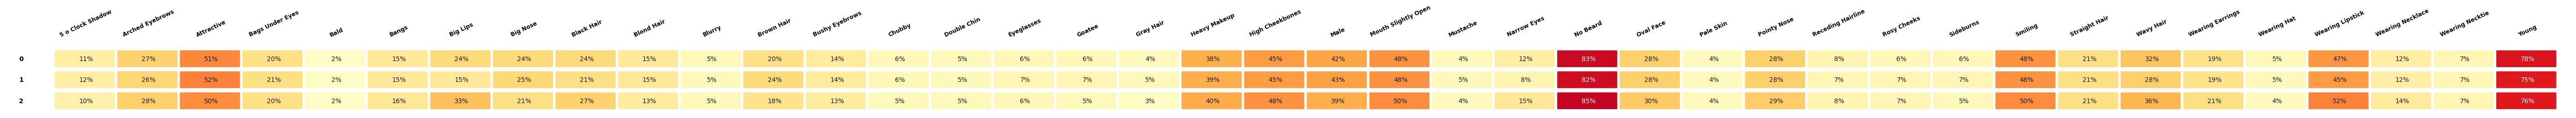

In [24]:
plot_table_attr(attr_binary, colonnes_attributs)

### Entraîner un modèle en utilisant les images en entrée et l’attribut Smiling.. Justifier le choix de votre modèle. Décrivez et commentez les résultats.

### Évaluation de l’équité: Comparer les performances par sous-groupes sensibles : (e.g. Accuracy par genre, FPR / FNR par groupe, Écart de performance entre groupes)

## 3. Explication post-hoc

### Appliquez deux méthodes d’explication post-hoc

### Générer des explications locales pour un cas correct, un cas incorrect et un cas de groupe minoritaire

### commenter et conclure sur votre modèle.

### Si le modèle n’a pas appris le bon concept, proposer une intervention et recommencer.